# KabyLLM v2 · pretrain on Kabyle, then fine-tune on the discussion

Run 1 trained a model on the discussion alone. After about 11 passes it started memorizing (best validation loss 4.04),
because 570K tokens of chat are not enough to learn a language.

This notebook still trains **from scratch** (no existing model is used), in two stages:
1. **Pretraining** on a Kabyle corpus of 120M characters (Wikipedia, books, sentence collections), converted to the
   spelling used in the chat (`ɣ → gh`, `ɛ → 3`, `c → ch`, …). The model learns Kabyle words, conjugation and grammar.
2. **Fine-tuning** on the discussion. The model learns the chat itself: abbreviations (`nrml`, `drct`), French, emojis,
   and the way messages follow each other.

In each stage the model answers **"amek achu xedmed akka"** at 0%, 10%, … 100% of training (11 answers per stage).
At the end the result is compared with run 1 on the same validation messages, the model is saved, and you can chat with it.

**Running on Kaggle**
- *Add Input*: a dataset containing `discussion.txt` and `kabyle_corpus.txt.gz`. Both are found automatically under `/kaggle/input`.
- *Settings → Accelerator → GPU T4 ×1*.
- Expect roughly an hour or more, almost all of it pretraining. The progress bar shows the remaining time.
- The pretrained model is saved before fine-tuning, so fine-tuning can be re-run alone in a few minutes (section 11).
- If the interactive session risks timing out, use *Save Version → Save & Run All*: it runs in the background and keeps
  the files of `/kaggle/working` as output. `chat()` needs a keyboard, so in that mode only the `ask()` answers are shown.

### Design choices

| | Choice | Why |
|---|---|---|
| **Corpus spelling** | Kabyle letters converted to chat spelling, hyphens removed (`yenna-yas → yennayas`) | After conversion, 77% of the words written in the discussion also appear in the corpus, against 69% before. |
| **Tokenizer** | Byte-level BPE, 8,192 tokens, trained on the corpus plus the discussion counted 10 times | Chat words such as `xedmed`, `hhhh`, `nrml` stay single tokens. |
| **Architecture** | Decoder-only Transformer: RMSNorm, rotary position embeddings, SwiGLU, tied embeddings | Same as run 1; only the size changes. |
| **Size** | 10 layers · 512 dimensions · 8 heads · 512-token context · ≈ 36M parameters | 35M corpus tokens can feed a model 3× larger than run 1. |
| **Pretraining** | 3 passes over the corpus, learning rate 6e-4 → 6e-5, no dropout | Up to about 4 passes, repeated text is almost as useful as new text, so dropout is not needed. |
| **Fine-tuning** | 300 steps, learning rate 3e-4 → 3e-5, dropout 0.1, 20% of every batch still taken from the corpus | The lower learning rate keeps what pretraining learned. Mixing in corpus text delays memorization of the discussion. |
| **Evaluation** | The same 6,600 validation messages as run 1, in bits per character | A per-character loss can be compared across tokenizers. Run 1 scored 2.05. |

## 1 · Setup

In [1]:
import contextlib, glob, gzip, math, os, random, re, textwrap, time
from collections import Counter
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm

SEED = 1337
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    gpu = torch.cuda.get_device_properties(0)
    # Turing GPUs (T4) have no bfloat16 → float16 with loss scaling. Ampere and newer → bfloat16.
    AMP_DTYPE = torch.bfloat16 if gpu.major >= 8 else torch.float16
    print(f"GPU       : {gpu.name} · {gpu.total_memory / 1024**3:.1f} GB · compute capability {gpu.major}.{gpu.minor}")
else:
    AMP_DTYPE = None
    print("GPU       : none found, training on CPU will be very slow (Kaggle: Settings → Accelerator → GPU T4)")
print(f"PyTorch   : {torch.__version__}")
print(f"Precision : {'mixed ' + str(AMP_DTYPE).removeprefix('torch.') if AMP_DTYPE else 'float32'}")


def amp_context():
    """Mixed-precision autocast on GPU, no-op on CPU."""
    return torch.autocast("cuda", dtype=AMP_DTYPE) if AMP_DTYPE else contextlib.nullcontext()


def fmt_time(seconds):
    minutes, seconds = divmod(int(seconds), 60)
    hours, minutes = divmod(minutes, 60)
    return f"{hours}h {minutes:02d}m" if hours else f"{minutes}m {seconds:02d}s"


def find_input(*names):
    """First file named one of `names` under /kaggle/input, then under the current folder."""
    for root in ("/kaggle/input", "."):
        for name in names:
            hits = sorted(glob.glob(os.path.join(root, "**", name), recursive=True))
            if hits:
                return hits[0]
    raise FileNotFoundError(f"{' / '.join(names)} not found. Add it as a Kaggle dataset, or set its path in the configuration cell.")

GPU       : Tesla T4 · 14.6 GB · compute capability 7.5
PyTorch   : 2.10.0+cu128
Precision : mixed float16


## 2 · Configuration

Every setting lives here.

In [2]:
# ── Data ─────────────────────────────────────────────────────────────────────
CHAT_FILE           = None     # None → find discussion.txt
CORPUS_FILE         = None     # None → find kabyle_corpus.txt.gz (or kabyle_corpus.txt)
CORPUS_MAX_LINES    = None     # e.g. 100_000 for a quick test run on part of the corpus
OUTPUT_DIR          = "/kaggle/working" if os.path.isdir("/kaggle/working") else "outputs"
MAX_CHAR_REPEAT     = 4        # "Sahiiiiiiiit" → "Sahiiiit"   (None keeps text as is)
CHAT_VAL_FRACTION   = 0.10     # same validation split as run 1: blocks of 200 consecutive messages
CHAT_VAL_BLOCK      = 200
CORPUS_VAL_FRACTION = 0.005    # blocks of 1,000 consecutive corpus lines
CORPUS_VAL_BLOCK    = 1000

# ── Tokenizer ────────────────────────────────────────────────────────────────
VOCAB_SIZE          = 8192
TOKENIZER_CHAT_WEIGHT = 10     # the discussion counts 10× when the tokenizer picks its tokens

# ── Model (≈ 36M parameters) ─────────────────────────────────────────────────
CONTEXT_LEN         = 512
D_MODEL             = 512
N_LAYERS            = 10
N_HEADS             = 8
FFN_HIDDEN          = 1408     # SwiGLU hidden size, ≈ 8/3 × D_MODEL

# ── Stage 1 · pretraining on the corpus ──────────────────────────────────────
PRETRAINED_CHECKPOINT = None   # path to a kabyle_gpt_pretrained.pt from an earlier run → stage 1 is skipped
PRETRAIN_EPOCHS     = 3        # passes over the corpus
PRETRAIN_BATCH      = 32       # × 512 = 16,384 tokens per step
PRETRAIN_LR         = 6e-4
PRETRAIN_MIN_LR     = 6e-5
PRETRAIN_WARMUP     = 300
PRETRAIN_DROPOUT    = 0.0
PRETRAIN_EVALS      = 30       # silent evaluations, shown in the progress bar

# ── Stage 2 · fine-tuning on the discussion ──────────────────────────────────
FINETUNE_ITERS      = 300
FINETUNE_BATCH      = 16       # × 512 = 8,192 tokens per step
FINETUNE_REPLAY     = 0.2      # share of each batch taken from the corpus
FINETUNE_LR         = 3e-4
FINETUNE_MIN_LR     = 3e-5
FINETUNE_WARMUP     = 30
FINETUNE_DROPOUT    = 0.1
FINETUNE_EVALS      = 20

# ── Both stages ──────────────────────────────────────────────────────────────
WEIGHT_DECAY        = 0.1
GRAD_CLIP           = 1.0

# ── Progress snapshots and chat ──────────────────────────────────────────────
PROBE_PROMPT        = "amek achu xedmed akka"
N_SNAPSHOTS         = 11       # answers at 0%, 10%, …, 100% of each stage
REPLY_MESSAGES      = 3        # a reply = the next N messages the model writes
MAX_REPLY_TOKENS    = 120
TEMPERATURE         = 0.8
TOP_K               = 50
TOP_P               = 0.95
SNAPSHOT_SEED       = 42       # same seed at every snapshot, so answers differ because of training, not luck

RUN1_CHAT_VAL_BPC   = 2.046    # run 1 (11.4M parameters, discussion only): val loss 4.039 per token = 2.046 bits per character

os.makedirs(OUTPUT_DIR, exist_ok=True)
PRETRAINED_PATH = os.path.join(OUTPUT_DIR, "kabyle_gpt_pretrained.pt")
FINETUNED_PATH = os.path.join(OUTPUT_DIR, "kabyle_gpt.pt")

## 3 · The discussion

Same cleaning as run 1: "message deleted" notices, edit tags, links, e-mail addresses and phone numbers are removed.
The validation messages are the same as in run 1, so the two runs can be compared.

In [3]:
RE_NOTICE = re.compile(r"^(?:Vous avez supprimé ce message|Ce message a été supprimé)\.?$", re.IGNORECASE)
RE_TAG    = re.compile(r"<[^<>]*(?:modifié|omis|supprimé)[^<>]*>", re.IGNORECASE)
RE_URL    = re.compile(r"(?:https?://|\bwww\.)\S+", re.IGNORECASE)
RE_EMAIL  = re.compile(r"\S+@\S+\.[a-z]{2,}", re.IGNORECASE)
RE_PHONE  = re.compile(r"(?:\+|\b00)\d{3}[\s.-]?\d(?:[\s.-]?\d{2}){4}\b|\b0[5-7]\d{2}(?:[\s.-]?\d{2}){3}\b")
RE_REPEAT = re.compile(r"(.{1,2}?)\1{%d,}" % MAX_CHAR_REPEAT) if MAX_CHAR_REPEAT else None


def clean_message(line, stats):
    """Return the cleaned message, or None if nothing worth keeping is left."""
    line = line.strip()
    if not line:
        stats["empty lines"] += 1
        return None
    if RE_NOTICE.match(line):
        stats["'message deleted' notices"] += 1
        return None
    for label, pattern in (("edit / voice-note tags", RE_TAG), ("links", RE_URL),
                           ("e-mail addresses", RE_EMAIL), ("phone numbers", RE_PHONE)):
        line, n = pattern.subn("", line)
        stats[label] += n
    if RE_REPEAT:
        line, n = RE_REPEAT.subn(lambda m: m.group(1) * MAX_CHAR_REPEAT, line)
        stats["long repetitions shortened"] += n
    line = re.sub(r"\s+", " ", line).strip()
    if not line:
        stats["lines left empty after cleaning"] += 1
        return None
    return line


def block_split(items, block, fraction, seed):
    """Split a list into (train, val), where val is a random set of blocks of consecutive items."""
    n_blocks = math.ceil(len(items) / block)
    val_blocks = set(random.Random(seed).sample(range(n_blocks), max(1, round(n_blocks * fraction))))
    train = [x for i, x in enumerate(items) if i // block not in val_blocks]
    val = [x for i, x in enumerate(items) if i // block in val_blocks]
    return train, val


chat_path = CHAT_FILE or find_input("discussion.txt")
with open(chat_path, encoding="utf-8") as f:
    raw_chat = f.read().splitlines()
cleaning_stats = Counter()
chat_messages = [m for m in (clean_message(line, cleaning_stats) for line in raw_chat) if m is not None]
chat_train_msgs, chat_val_msgs = block_split(chat_messages, CHAT_VAL_BLOCK, CHAT_VAL_FRACTION, SEED)

print(f"File       : {chat_path}")
print(f"Messages   : {len(raw_chat):,} lines → {len(chat_messages):,} kept "
      f"({len(chat_train_msgs):,} train · {len(chat_val_msgs):,} validation)")
print("Cleaning   : " + " · ".join(f"{label} {n:,}" for label, n in cleaning_stats.items()))

File       : /kaggle/input/datasets/amarmerabti/dataset-kabyle/discussion.txt
Messages   : 66,914 lines → 66,497 kept (59,897 train · 6,600 validation)
Cleaning   : edit / voice-note tags 70 · links 21 · e-mail addresses 6 · phone numbers 1 · long repetitions shortened 2,468 · empty lines 324 · 'message deleted' notices 62 · lines left empty after cleaning 31


## 4 · The Kabyle corpus, converted to chat spelling

The corpus uses standard Kabyle orthography, while the discussion is typed on a phone keyboard. Each line is converted:

| corpus | ɣ | ɛ | c | č | ǧ | ḍ ṭ ṣ ẓ ḥ ṛ | `yenna-yas` |
|---|---|---|---|---|---|---|---|
| **chat** | gh | 3 | ch | ch | j | d t s z h r | `yennayas` |

Leftover HTML tags and PDF symbols are removed, and duplicate lines are dropped.

In [4]:
TO_CHAT_SPELLING = str.maketrans({
    "ɣ": "gh", "Ɣ": "Gh", "ɛ": "3", "Ɛ": "3", "c": "ch", "C": "Ch", "č": "ch", "Č": "Ch", "ǧ": "j", "Ǧ": "J",
    "ḍ": "d", "Ḍ": "D", "ṭ": "t", "Ṭ": "T", "ṣ": "s", "Ṣ": "S", "ẓ": "z", "Ẓ": "Z", "ḥ": "h", "Ḥ": "H",
    "ṛ": "r", "Ṛ": "R", "ə": "e", "«": '"', "»": '"',
})
RE_CLITIC_HYPHEN = re.compile(r"(?<=[^\W\d_])-(?=[^\W\d_])")            # letter-letter hyphens only
RE_JUNK = re.compile(r"</?[a-zA-Z][^<>]{0,40}>|[-]")         # HTML tags, private-use PDF symbols


def to_chat_spelling(line):
    line = RE_JUNK.sub("", line).translate(TO_CHAT_SPELLING)
    if "-" in line:
        line = RE_CLITIC_HYPHEN.sub("", line)
    return " ".join(line.split())


corpus_path = CORPUS_FILE or find_input("kabyle_corpus.txt.gz", "kabyle_corpus.txt")
open_corpus = gzip.open if corpus_path.endswith(".gz") else open
corpus_lines, seen, examples = [], set(), []
n_read = n_duplicates = 0
start = time.time()
with open_corpus(corpus_path, "rt", encoding="utf-8") as f:
    for raw in tqdm(f, desc="Reading corpus", unit=" lines", mininterval=1, leave=False):
        if CORPUS_MAX_LINES and n_read >= CORPUS_MAX_LINES:
            break
        n_read += 1
        line = to_chat_spelling(raw)
        if not line:
            continue
        if line in seen:
            n_duplicates += 1
            continue
        seen.add(line)
        corpus_lines.append(line)
        if len(examples) < 4 and 40 < len(raw) < 110 and ("ɣ" in raw or "-" in raw):
            examples.append((raw.strip(), line))
del seen
corpus_train_lines, corpus_val_lines = block_split(corpus_lines, CORPUS_VAL_BLOCK, CORPUS_VAL_FRACTION, SEED + 1)

print(f"File       : {corpus_path}")
print(f"Lines      : {n_read:,} read → {len(corpus_lines):,} kept ({n_duplicates:,} duplicates removed) · {fmt_time(time.time() - start)}")
print(f"Characters : {sum(map(len, corpus_lines)):,} · {len(corpus_train_lines):,} train lines · {len(corpus_val_lines):,} validation lines")
print("\nSpelling conversion examples")
for before, after in examples:
    print(f"  before │ {before}\n  after  │ {after}\n")

File       : /kaggle/input/datasets/amarmerabti/dataset-kabyle/kabyle_corpus.txt
Lines      : 1,061,644 read → 1,016,430 kept (45,163 duplicates removed) · 0m 26s
Characters : 119,962,320 · 1,011,430 train lines · 5,000 validation lines

Spelling conversion examples
  before │ Ḍefreɣ yiwen n webin ɣef tsertit tabeṛṛanit, yella igerrez s tidet.
  after  │ Defregh yiwen n webin ghef tsertit taberranit, yella igerrez s tidet.

  before │ Iswi n umaru yebɣa ad yessebgen , d lmuḥal ad yuɣal winna i xedɛen
  after  │ Iswi n umaru yebgha ad yessebgen , d lmuhal ad yughal winna i xed3en

  before │ Amsestan : tikkwal ɣ efṛ ṛ ebɛ a tikkwal ɣ ef lxemsa
  after  │ Amsestan : tikkwal gh efr r eb3 a tikkwal gh ef lxemsa

  before │ Tifunasin ttakent-aɣ-d ayefki, tiyuzaḍ, d timellalin.
  after  │ Tifunasin ttakentaghd ayefki, tiyuzad, d timellalin.



## 5 · Tokenizer

Byte-level BPE starts from the 256 bytes and repeatedly merges the most frequent pair of tokens until it has `VOCAB_SIZE` tokens.
It is trained on the corpus plus the training messages of the discussion, counted `TOKENIZER_CHAT_WEIGHT` times.
Then every text is turned into one long stream of tokens, with a `<|msg|>` token after each message or corpus line.

In [5]:
from tokenizers import Tokenizer, Regex, decoders, models, pre_tokenizers, trainers

MSG_TOKEN = "<|msg|>"
# Text is first cut into words, then BPE works inside each word. Unlike GPT-2's rule, digits stay attached
# to letters, because in romanized Kabyle they are letters (3 = ɛ, as in "Ma3lich").
WORD_SPLIT = r" ?[\p{L}\p{N}][\p{L}\p{N}\p{M}]*| ?[^\s\p{L}\p{N}]+|\s+"

pretrained_ckpt = None
start = time.time()
if PRETRAINED_CHECKPOINT:
    pretrained_ckpt = torch.load(PRETRAINED_CHECKPOINT, map_location="cpu", weights_only=True)
    tokenizer = Tokenizer.from_str(pretrained_ckpt["tokenizer"])
    CONTEXT_LEN = pretrained_ckpt["model_config"]["context_len"]
    print(f"Tokenizer loaded from {PRETRAINED_CHECKPOINT}")
else:
    def tokenizer_training_text():
        for _ in range(TOKENIZER_CHAT_WEIGHT):
            yield from chat_train_msgs
        yield from corpus_train_lines

    tokenizer = Tokenizer(models.BPE())
    tokenizer.pre_tokenizer = pre_tokenizers.Sequence([
        pre_tokenizers.Split(Regex(WORD_SPLIT), behavior="isolated"),
        pre_tokenizers.ByteLevel(add_prefix_space=False, use_regex=False),
    ])
    tokenizer.decoder = decoders.ByteLevel()
    tokenizer.train_from_iterator(tokenizer_training_text(), trainers.BpeTrainer(
        vocab_size=VOCAB_SIZE, min_frequency=2, special_tokens=[MSG_TOKEN],
        initial_alphabet=pre_tokenizers.ByteLevel.alphabet(), show_progress=False,
    ))
MSG_ID = tokenizer.token_to_id(MSG_TOKEN)


def encode_stream(lines, desc):
    """All lines as one token tensor on the GPU: <|msg|> line <|msg|> line <|msg|> …"""
    parts = [np.array([MSG_ID], dtype=np.int32)]
    for i in tqdm(range(0, len(lines), 20_000), desc=desc, leave=False):
        ids = [t for e in tokenizer.encode_batch(lines[i:i + 20_000]) for t in (*e.ids, MSG_ID)]
        parts.append(np.array(ids, dtype=np.int32))
    return torch.from_numpy(np.concatenate(parts)).to(DEVICE)


corpus_train = encode_stream(corpus_train_lines, "Tokenizing corpus")
corpus_val = encode_stream(corpus_val_lines, "Tokenizing corpus validation")
chat_train = encode_stream(chat_train_msgs, "Tokenizing discussion")
chat_val = encode_stream(chat_val_msgs, "Tokenizing discussion validation")


def show_tokens(text):
    return " ".join(f"[{tokenizer.decode([i])}]" for i in tokenizer.encode(text).ids)


print(f"Vocabulary : {tokenizer.get_vocab_size():,} tokens · {fmt_time(time.time() - start)}")
print(f"Characters per token : discussion {sum(map(len, chat_train_msgs)) / len(chat_train):.2f} · "
      f"corpus {sum(map(len, corpus_train_lines)) / len(corpus_train):.2f}")
print("\nToken streams")
for name, stream in (("corpus train", corpus_train), ("corpus validation", corpus_val),
                     ("discussion train", chat_train), ("discussion validation", chat_val)):
    print(f"  {name:<22}{len(stream):>13,} tokens")
print("\nExamples")
for text in (PROBE_PROMPT, "Ma3lich 😂😂😂 nrml", "Yella yiwen wergaz di taddart"):
    print(f"  {text!r:<32} → {show_tokens(text)}")

Vocabulary : 8,192 tokens · 1m 06s
Characters per token : discussion 3.08 · corpus 3.34

Token streams
  corpus train             35,759,828 tokens
  corpus validation           172,887 tokens
  discussion train            524,308 tokens
  discussion validation        58,006 tokens

Examples
  'amek achu xedmed akka'          → [amek] [ achu] [ xedmed] [ akka]
  'Yella yiwen wergaz di taddart'  → [Yella] [ yiwen] [ wergaz] [ di] [ taddart]


## 6 · Batches and evaluation sets

A training example is a random window of `CONTEXT_LEN` tokens; the model learns to predict every next token.
Evaluations always use the same windows, so losses are comparable from one check to the next.
The discussion is evaluated on windows of 256 tokens, as in run 1.

In [6]:
CHAT_EVAL_LEN = min(256, CONTEXT_LEN)


def random_windows(data, n):
    starts = torch.randint(len(data) - CONTEXT_LEN - 1, (n, 1), device=data.device)
    windows = data[starts + torch.arange(CONTEXT_LEN + 1, device=data.device)].long()
    return windows[:, :-1], windows[:, 1:]


def fixed_windows(data, starts, length):
    windows = data[starts[:, None] + torch.arange(length + 1, device=data.device)].long()
    return windows[:, :-1], windows[:, 1:]


def consecutive_windows(data, length, max_windows=None):
    n = (len(data) - 1) // length
    return fixed_windows(data, torch.arange(min(n, max_windows or n), device=data.device) * length, length)


def pretrain_batch():
    return random_windows(corpus_train, PRETRAIN_BATCH)


def finetune_batch():
    n_corpus = round(FINETUNE_BATCH * FINETUNE_REPLAY)
    x, y = random_windows(chat_train, FINETUNE_BATCH - n_corpus)
    if n_corpus:
        xc, yc = random_windows(corpus_train, n_corpus)
        x, y = torch.cat([x, xc]), torch.cat([y, yc])
    return x, y


eval_chat_val = consecutive_windows(chat_val, CHAT_EVAL_LEN)
eval_chat_train = fixed_windows(chat_train, torch.randint(len(chat_train) - CHAT_EVAL_LEN - 1, (len(eval_chat_val[0]),),
                                                          generator=torch.Generator().manual_seed(SEED)).to(DEVICE), CHAT_EVAL_LEN)
eval_corpus_val = consecutive_windows(corpus_val, CONTEXT_LEN, max_windows=256)

chat_val_chars = sum(map(len, chat_val_msgs))


def bits_per_char(chat_val_loss):
    """Convert a loss per token on the discussion validation set into bits per character."""
    return chat_val_loss / math.log(2) * len(chat_val) / chat_val_chars


pretrain_steps = math.ceil(PRETRAIN_EPOCHS * len(corpus_train) / (PRETRAIN_BATCH * CONTEXT_LEN))
n_replay = round(FINETUNE_BATCH * FINETUNE_REPLAY)
if pretrained_ckpt:
    print(f"Stage 1 · pretraining : skipped, weights from {PRETRAINED_CHECKPOINT}")
else:
    print(f"Stage 1 · pretraining : {pretrain_steps:,} steps × {PRETRAIN_BATCH * CONTEXT_LEN:,} tokens = "
          f"{pretrain_steps * PRETRAIN_BATCH * CONTEXT_LEN / 1e6:.1f}M tokens ({PRETRAIN_EPOCHS} passes over the corpus)")
print(f"Stage 2 · fine-tuning : {FINETUNE_ITERS:,} steps × {FINETUNE_BATCH * CONTEXT_LEN:,} tokens "
      f"({FINETUNE_BATCH - n_replay} discussion + {n_replay} corpus windows) ≈ "
      f"{FINETUNE_ITERS * (FINETUNE_BATCH - n_replay) * CONTEXT_LEN / len(chat_train):.1f} passes over the discussion")
print(f"Evaluation            : discussion {len(eval_chat_val[0])} windows · corpus {len(eval_corpus_val[0])} windows")

Stage 1 · pretraining : 6,548 steps × 16,384 tokens = 107.3M tokens (3 passes over the corpus)
Stage 2 · fine-tuning : 300 steps × 8,192 tokens (13 discussion + 3 corpus windows) ≈ 3.8 passes over the discussion
Evaluation            : discussion 226 windows · corpus 256 windows


## 7 · Model architecture

```
tokens → embedding → [ RMSNorm → causal self-attention (RoPE) → + ]  × N_LAYERS → RMSNorm → linear → next-token scores
                     [ RMSNorm → SwiGLU feed-forward           → + ]
```
- **RMSNorm** rescales vectors before each sub-layer ("pre-norm"), which keeps training stable.
- **Causal self-attention** lets each token look at earlier tokens only. **RoPE** encodes positions by rotating queries and keys.
- **SwiGLU** is a gated feed-forward layer. It trains better than the classic GELU MLP.
- **Weight tying**: the output layer reuses the embedding matrix.

In [7]:
@dataclass
class ModelConfig:
    vocab_size: int
    context_len: int = 512
    d_model: int = 512
    n_layers: int = 10
    n_heads: int = 8
    ffn_hidden: int = 1408
    dropout: float = 0.0
    rope_theta: float = 10_000.0


class RMSNorm(nn.Module):
    """Divide each vector by its root-mean-square, then apply a learned per-channel gain."""

    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        x_float = x.float()  # computed in float32 for stability under fp16
        normed = x_float * torch.rsqrt(x_float.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return normed.type_as(x) * self.weight


def rope_tables(cfg):
    """cos / sin of the rotation angles for every (position, frequency): shape (context_len, head_dim / 2)."""
    head_dim = cfg.d_model // cfg.n_heads
    inv_freq = 1.0 / (cfg.rope_theta ** (torch.arange(0, head_dim, 2).float() / head_dim))
    angles = torch.outer(torch.arange(cfg.context_len).float(), inv_freq)
    return angles.cos(), angles.sin()


def apply_rope(x, cos, sin):
    """Rotate channel pairs of x (batch, heads, time, head_dim) by position-dependent angles."""
    x1, x2 = x.chunk(2, dim=-1)
    cos, sin = cos.to(x.dtype), sin.to(x.dtype)
    return torch.cat([x1 * cos - x2 * sin, x1 * sin + x2 * cos], dim=-1)


class CausalSelfAttention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        assert cfg.d_model % cfg.n_heads == 0, "D_MODEL must be divisible by N_HEADS"
        self.n_heads = cfg.n_heads
        self.dropout = cfg.dropout
        self.w_qkv = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=False)
        self.w_out = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.out_dropout = nn.Dropout(cfg.dropout)

    def forward(self, x, cos, sin):
        B, T, C = x.shape
        q, k, v = self.w_qkv(x).split(C, dim=-1)
        q, k, v = (t.view(B, T, self.n_heads, C // self.n_heads).transpose(1, 2) for t in (q, k, v))
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        # Fused attention kernel; is_causal=True hides future tokens.
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True,
                                           dropout_p=self.dropout if self.training else 0.0)
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_dropout(self.w_out(y))


class SwiGLU(nn.Module):
    """Gated feed-forward layer: w_down( SiLU(w_gate(x)) * w_up(x) )."""

    def __init__(self, cfg):
        super().__init__()
        self.w_gate = nn.Linear(cfg.d_model, cfg.ffn_hidden, bias=False)
        self.w_up = nn.Linear(cfg.d_model, cfg.ffn_hidden, bias=False)
        self.w_down = nn.Linear(cfg.ffn_hidden, cfg.d_model, bias=False)
        self.dropout = nn.Dropout(cfg.dropout)

    def forward(self, x):
        return self.dropout(self.w_down(F.silu(self.w_gate(x)) * self.w_up(x)))


class Block(nn.Module):
    """One Transformer layer: x + attention(norm(x)), then x + feed_forward(norm(x))."""

    def __init__(self, cfg):
        super().__init__()
        self.attn_norm = RMSNorm(cfg.d_model)
        self.attn = CausalSelfAttention(cfg)
        self.ffn_norm = RMSNorm(cfg.d_model)
        self.ffn = SwiGLU(cfg)

    def forward(self, x, cos, sin):
        x = x + self.attn(self.attn_norm(x), cos, sin)
        return x + self.ffn(self.ffn_norm(x))


class KabyleGPT(nn.Module):
    def __init__(self, cfg: ModelConfig):
        super().__init__()
        self.cfg = cfg
        self.tok_emb = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.emb_dropout = nn.Dropout(cfg.dropout)
        self.blocks = nn.ModuleList([Block(cfg) for _ in range(cfg.n_layers)])
        self.final_norm = RMSNorm(cfg.d_model)
        self.lm_head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.lm_head.weight = self.tok_emb.weight  # weight tying

        cos, sin = rope_tables(cfg)
        self.register_buffer("rope_cos", cos, persistent=False)
        self.register_buffer("rope_sin", sin, persistent=False)

        self.apply(self._init_weights)
        # GPT-2 initialization: layers writing into the residual stream start smaller, so its scale does not grow with depth.
        for name, p in self.named_parameters():
            if name.endswith(("w_out.weight", "w_down.weight")):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * cfg.n_layers))

    @staticmethod
    def _init_weights(module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        T = idx.size(1)
        assert T <= self.cfg.context_len, f"{T} tokens exceed the context length ({self.cfg.context_len})"
        x = self.emb_dropout(self.tok_emb(idx))
        cos, sin = self.rope_cos[:T], self.rope_sin[:T]
        for block in self.blocks:
            x = block(x, cos, sin)
        logits = self.lm_head(self.final_norm(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.float().view(-1, logits.size(-1)), targets.reshape(-1))
        return logits, loss


def set_dropout(model, p):
    """Change the dropout rate of every layer (pretraining and fine-tuning use different rates)."""
    model.cfg.dropout = p
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.p = p
        elif isinstance(module, CausalSelfAttention):
            module.dropout = p

In [8]:
if pretrained_ckpt:
    model_cfg = ModelConfig(**pretrained_ckpt["model_config"])
    print("Architecture taken from the pretrained checkpoint (the model settings of section 2 are ignored).\n")
else:
    model_cfg = ModelConfig(vocab_size=tokenizer.get_vocab_size(), context_len=CONTEXT_LEN, d_model=D_MODEL,
                            n_layers=N_LAYERS, n_heads=N_HEADS, ffn_hidden=FFN_HIDDEN, dropout=PRETRAIN_DROPOUT)
model = KabyleGPT(model_cfg).to(DEVICE)

param_counts = dict.fromkeys(["Token embeddings (shared with output)", "Attention", "Feed-forward (SwiGLU)", "RMSNorm gains"], 0)
for name, p in model.named_parameters():  # the tied output layer is listed once, under tok_emb
    param_counts["Token embeddings (shared with output)" if name.startswith("tok_emb") else
                 "Attention" if ".attn." in name else
                 "Feed-forward (SwiGLU)" if ".ffn." in name else
                 "RMSNorm gains"] += p.numel()
n_params = sum(param_counts.values())

print(f"KabyleGPT · {model_cfg.n_layers} layers · d_model {model_cfg.d_model} · {model_cfg.n_heads} heads of "
      f"{model_cfg.d_model // model_cfg.n_heads} dims · SwiGLU {model_cfg.ffn_hidden} · context {model_cfg.context_len} tokens · "
      f"vocabulary {model_cfg.vocab_size:,}\n")
for label, count in param_counts.items():
    print(f"  {label:<40}{count:>12,}")
print(f"  {'─' * 52}\n  {'Total':<40}{n_params:>12,}  ({n_params / 1e6:.1f}M)")

KabyleGPT · 10 layers · d_model 512 · 8 heads of 64 dims · SwiGLU 1408 · context 512 tokens · vocabulary 8,192

  Token embeddings (shared with output)      4,194,304
  Attention                                 10,485,760
  Feed-forward (SwiGLU)                     21,626,880
  RMSNorm gains                                 10,752
  ────────────────────────────────────────────────────
  Total                                     36,317,696  (36.3M)


## 8 · Text generation

The model writes one token at a time, drawn at random among the most likely ones
(**temperature** sharpens or flattens the choice, **top-k** / **top-p** drop unlikely tokens).
The conversation is fed as `<|msg|> message <|msg|> message <|msg|>`, and generation stops after `REPLY_MESSAGES` messages.

`ask("…")` answers one message and `chat()` holds a conversation; both are used in section 14.

In [9]:
def encode(text):
    return tokenizer.encode(text).ids


@torch.no_grad()
def generate_messages(model, conversation, n_messages=REPLY_MESSAGES, max_new_tokens=MAX_REPLY_TOKENS,
                      temperature=TEMPERATURE, top_k=TOP_K, top_p=TOP_P, seed=None):
    """Continue a conversation (list of message strings) and return the next n_messages messages."""
    was_training = model.training
    model.eval()
    ids = [MSG_ID]
    for message in conversation:
        ids += encode(message) + [MSG_ID]
    idx = torch.tensor([ids], dtype=torch.long, device=DEVICE)
    generator = torch.Generator(device=DEVICE).manual_seed(seed) if seed is not None else None

    replies, current = [], []
    for _ in range(max_new_tokens):
        with amp_context():
            logits, _ = model(idx[:, -model.cfg.context_len:])
        logits = logits[0, -1].float() / max(temperature, 1e-5)
        if top_k:
            kth_best = torch.topk(logits, min(top_k, logits.numel())).values[-1]
            logits[logits < kth_best] = float("-inf")
        if top_p < 1.0:
            sorted_logits, order = torch.sort(logits, descending=True)
            sorted_probs = sorted_logits.softmax(-1)
            outside = sorted_probs.cumsum(-1) - sorted_probs > top_p  # the most likely token is always kept
            logits[order[outside]] = float("-inf")
        next_id = torch.multinomial(logits.softmax(-1), 1, generator=generator)
        idx = torch.cat([idx, next_id.view(1, 1)], dim=1)

        token = next_id.item()
        if token != MSG_ID:
            current.append(token)
            continue
        text = tokenizer.decode(current).strip()
        current = []
        if text:
            replies.append(text)
            if len(replies) == n_messages:
                break
    if current:  # ran out of tokens in the middle of a message
        replies.append(tokenizer.decode(current).strip() + " …")
    model.train(was_training)
    return replies


def format_exchange(prompt, replies, indent="    ", width=110):
    lines = [f"{indent}you   › {prompt}"]
    for i, reply in enumerate(replies or ["(no answer)"]):
        prefix = indent + ("model › " if i == 0 else "        ")
        lines.append(textwrap.fill(reply, width=width, initial_indent=prefix,
                                   subsequent_indent=" " * len(prefix)) or prefix)
    return "\n".join(lines)


def ask(message, **options):
    print(format_exchange(message, generate_messages(model, [message], **options)), end="\n\n")


def chat(n_messages=REPLY_MESSAGES, **options):
    print("Chat with KabyleGPT · 'reset' starts over · 'quit' stops\n")
    conversation = []
    while True:
        try:
            message = input("you › ").strip()
        except (NotImplementedError, EOFError):
            print("(No keyboard input in this session. Use ask(\"...\") instead.)")
            return
        except KeyboardInterrupt:
            print("Bye!")
            return
        if message.lower() in {"quit", "exit", "q"}:
            print("Bye!")
            return
        if message.lower() == "reset":
            conversation = []
            print("(new conversation)\n")
            continue
        if not message:
            continue
        conversation.append(message)
        replies = generate_messages(model, conversation, n_messages=n_messages, **options)
        conversation += [r.removesuffix(" …") for r in replies]
        for reply in replies or ["(no answer)"]:
            print(f"model › {reply}")
        print()

## 9 · Training loop

One function trains both stages:
- **AdamW** with weight decay on weight matrices only, **gradient clipping** at 1.0, **float16 mixed precision**.
- **Learning rate**: linear warmup, then cosine decay to the minimum.
- The evaluation sets are measured silently from time to time; the values appear in the progress bar.
- At 0%, 10%, … 100% the model answers `PROBE_PROMPT`.
- In fine-tuning, the weights with the best discussion validation loss are saved.

In [10]:
@torch.no_grad()
def evaluate(model, eval_sets, batch_size=32):
    was_training = model.training
    model.eval()
    losses = {}
    for name, (xs, ys) in eval_sets.items():
        total = 0.0
        for i in range(0, len(xs), batch_size):
            with amp_context():
                _, loss = model(xs[i:i + batch_size], ys[i:i + batch_size])
            total += loss.item() * len(xs[i:i + batch_size])
        losses[name] = total / len(xs)
    model.train(was_training)
    return losses


def save_checkpoint(model, path, **extra):
    torch.save({
        "model": model.state_dict(),
        "model_config": asdict(model.cfg),
        "tokenizer": tokenizer.to_str(),
        "msg_token": MSG_TOKEN,
        "sampling": {"temperature": TEMPERATURE, "top_k": TOP_K, "top_p": TOP_P, "reply_messages": REPLY_MESSAGES},
        **extra,
    }, path)


def snapshot_report(title, number, step, steps, losses, replies, elapsed):
    head = f" {title} {number:>2}/{N_SNAPSHOTS} · {round(100 * step / steps):>3}% · step {step:,}/{steps:,} "
    stats = " · ".join(f"{name} {value:.3f}" for name, value in losses.items())
    return "\n".join(["", "━━━" + head + "━" * max(0, 84 - len(head)),
                      f"    {stats} · elapsed {fmt_time(elapsed)}", format_exchange(PROBE_PROMPT, replies)])


def train_stage(title, model, *, steps, batch_fn, tokens_per_step, lr, min_lr, warmup, eval_sets, n_evals,
                select_on=None, checkpoint_path=None):
    """Train for `steps` steps. With `select_on`, the weights with the lowest loss on that
    evaluation set are saved to `checkpoint_path`. Returns (history, best, seconds)."""
    optimizer = torch.optim.AdamW(
        [{"params": [p for p in model.parameters() if p.dim() >= 2], "weight_decay": WEIGHT_DECAY},
         {"params": [p for p in model.parameters() if p.dim() < 2], "weight_decay": 0.0}],
        lr=lr, betas=(0.9, 0.95), **({"fused": True} if DEVICE == "cuda" else {}),
    )
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_DTYPE == torch.float16)

    def lr_at(step):
        if step < warmup:
            return lr * (step + 1) / warmup
        progress = min(1.0, (step - warmup) / max(1, steps - warmup))
        return min_lr + 0.5 * (lr - min_lr) * (1 + math.cos(math.pi * progress))

    def postfix():
        parts = [f"loss {smooth_loss:.3f}"] if smooth_loss is not None else []
        parts += [f"{name} {values[-1]:.3f}" for name, values in history.items() if name != "step"]
        if select_on:
            parts.append(f"best {best['loss']:.3f}")
        return " · ".join(parts + [f"lr {current_lr:.1e}"])

    snapshot_steps = [round(i * steps / (N_SNAPSHOTS - 1)) for i in range(N_SNAPSHOTS)]
    eval_steps = set(snapshot_steps) | set(range(0, steps + 1, max(1, steps // n_evals)))
    history = {"step": [], **{name: [] for name in eval_sets}}
    best = {"step": 0, "loss": float("inf")}
    smooth_loss, current_lr = None, lr_at(0)

    print(f"{title}: {steps:,} steps · {steps * tokens_per_step / 1e6:.1f}M tokens · "
          f"answers {PROBE_PROMPT!r} at 0%, 10%, …, 100%")
    model.train()
    start = time.time()
    bar = tqdm(total=steps, desc=title, unit="step", dynamic_ncols=True, smoothing=0.05)
    for step in range(steps + 1):
        if step in eval_steps:
            losses = evaluate(model, eval_sets)
            history["step"].append(step)
            for name, value in losses.items():
                history[name].append(value)
            if select_on and losses[select_on] < best["loss"]:
                best = {"step": step, "loss": losses[select_on]}
                save_checkpoint(model, checkpoint_path, stage=title, step=step, losses=losses)
            bar.set_postfix_str(postfix())

        if step in snapshot_steps:
            replies = generate_messages(model, [PROBE_PROMPT], seed=SNAPSHOT_SEED)
            tqdm.write(snapshot_report(title, snapshot_steps.index(step) + 1, step, steps, losses, replies, time.time() - start))

        if step == steps:
            break

        current_lr = lr_at(step)
        for group in optimizer.param_groups:
            group["lr"] = current_lr
        x, y = batch_fn()
        with amp_context():
            _, loss = model(x, y)
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        bar.update(1)
        if step % 10 == 0:  # reading the loss forces a GPU sync, so not at every step
            smooth_loss = loss.item() if smooth_loss is None else 0.8 * smooth_loss + 0.2 * loss.item()
            bar.set_postfix_str(postfix(), refresh=False)
    bar.close()

    seconds = time.time() - start
    print(f"\n{title} done in {fmt_time(seconds)} · {steps * tokens_per_step / seconds:,.0f} tokens/s (evaluations included)")
    return history, best, seconds

## 10 · Stage 1: pretraining on the Kabyle corpus

`corpus val` measures Kabyle in general. `chat val` is the discussion, which the model never sees in this stage:
if it goes down, what the model learns from the corpus carries over to the chat.
Answers here look like corpus sentences; the chat style comes in stage 2.

In [11]:
if pretrained_ckpt:
    model.load_state_dict(pretrained_ckpt["model"])
    pretrain_history = pretrained_ckpt.get("history")
    print(f"Stage 1 skipped: pretrained weights loaded from {PRETRAINED_CHECKPOINT}")
else:
    set_dropout(model, PRETRAIN_DROPOUT)
    pretrain_history, _, pretrain_seconds = train_stage(
        "Pretraining", model, steps=pretrain_steps, batch_fn=pretrain_batch,
        tokens_per_step=PRETRAIN_BATCH * CONTEXT_LEN, lr=PRETRAIN_LR, min_lr=PRETRAIN_MIN_LR, warmup=PRETRAIN_WARMUP,
        eval_sets={"corpus val": eval_corpus_val, "chat val": eval_chat_val}, n_evals=PRETRAIN_EVALS,
    )
    save_checkpoint(model, PRETRAINED_PATH, stage="pretrained", history=pretrain_history, seconds=pretrain_seconds)
    print(f"Pretrained model saved → {PRETRAINED_PATH} ({os.path.getsize(PRETRAINED_PATH) / 1024**2:.0f} MB)")

pretrain_chat_val = evaluate(model, {"chat val": eval_chat_val})["chat val"]
print(f"Discussion validation after pretraining only: {bits_per_char(pretrain_chat_val):.3f} bits per character "
      f"(run 1, trained on the discussion itself: {RUN1_CHAT_VAL_BPC:.3f})")

Pretraining: 6,548 steps · 107.3M tokens · answers 'amek achu xedmed akka' at 0%, 10%, …, 100%



━━━ Pretraining  1/11 ·   0% · step 0/6,548 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    corpus val 9.103 · chat val 9.110 · elapsed 0m 03s
    you   › amek achu xedmed akka
    model › wumiamekchiche3d�amekamekchichmaziNnabul tghaw ayen ttwas3am ttwasqedqedqedellihenza tasebhit
            Ahien tezgi tezgi GherSegamekamek Chha ChhaTamazight Tisdamsa useggasnninamekchhamekchh taswi3t
            tasekEmmughaledEmmerna umawal lwilayaem3ubrid 3erekkermayen LarSegSegSegSegekkerbur mziya tullas
            kaanamek Mdichqaldichdich Tis Werja...) mziyachhanit3am lwilayachhmirgherriyennulfadiwel ttawin
            ttawinchichSeg TawesWer wallagh tasek�ubridsdsdmayen iwatanWsn Tawes tasekazchhmirmir���ufegh
            tamezWsnWsn ixeddamenekka amaruzKechchKechch�֫ M …

━━━ Pretraining  2/11 ·  10% · step 655/6,548 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    corpus val 4.582 · chat val 8.016 · elapsed 4m 37s
    you   › amek achu xedmed akka
    model › Ad nurar kra n yemdanen akken ad

## 11 · Stage 2: fine-tuning on the discussion

This cell always starts again from the pretrained weights. To try other fine-tuning settings, change the `FINETUNE_*`
values in section 2, run that cell, then run this one again (a few minutes, no new pretraining).

In [12]:
model.load_state_dict(torch.load(PRETRAINED_CHECKPOINT or PRETRAINED_PATH, map_location=DEVICE, weights_only=True)["model"])
set_dropout(model, FINETUNE_DROPOUT)
finetune_history, finetune_best, finetune_seconds = train_stage(
    "Fine-tuning", model, steps=FINETUNE_ITERS, batch_fn=finetune_batch,
    tokens_per_step=FINETUNE_BATCH * CONTEXT_LEN, lr=FINETUNE_LR, min_lr=FINETUNE_MIN_LR, warmup=FINETUNE_WARMUP,
    eval_sets={"chat train": eval_chat_train, "chat val": eval_chat_val}, n_evals=FINETUNE_EVALS,
    select_on="chat val", checkpoint_path=FINETUNED_PATH,
)

best_step = finetune_best["step"]
print(f"Best discussion validation loss {finetune_best['loss']:.3f} at step {best_step:,} "
      f"({100 * best_step / FINETUNE_ITERS:.0f}% of fine-tuning) → {FINETUNED_PATH}")
val_at_80 = next(v for s, v in zip(finetune_history["step"], finetune_history["chat val"]) if s >= 0.8 * FINETUNE_ITERS)
if best_step < 0.7 * FINETUNE_ITERS:
    print("Validation loss stopped improving before the end: after that point the model was memorizing the discussion.\n"
          "The saved model is the best one. For a next try, lower FINETUNE_ITERS or raise FINETUNE_DROPOUT.")
elif best_step == FINETUNE_ITERS and val_at_80 - finetune_best["loss"] > 0.02:
    print("Validation loss was still going down at the end: more fine-tuning steps (FINETUNE_ITERS) may help.")

Fine-tuning: 300 steps · 2.5M tokens · answers 'amek achu xedmed akka' at 0%, 10%, …, 100%



━━━ Fine-tuning  1/11 ·   0% · step 0/300 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    chat train 7.591 · chat val 7.381 · elapsed 0m 01s

━━━ Fine-tuning  2/11 ·  10% · step 30/300 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    chat train 5.066 · chat val 5.079 · elapsed 0m 11s

━━━ Fine-tuning  3/11 ·  20% · step 60/300 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    chat train 4.556 · chat val 4.700 · elapsed 0m 20s

━━━ Fine-tuning  4/11 ·  30% · step 90/300 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    chat train 4.300 · chat val 4.539 · elapsed 0m 30s

━━━ Fine-tuning  5/11 ·  40% · step 120/300 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    chat train 4.115 · chat val 4.438 · elapsed 0m 39s

━━━ Fine-tuning  6/11 ·  50% · step 150/300 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    chat train 3.982 · chat val 4.359 · elapsed 0m 48s

━━━ Fine-tuning  7/11 ·  60% · step 180/300 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    chat train 3.894 · chat val 4.310 · elapsed

## 12 · Results

In [13]:
checkpoint = torch.load(FINETUNED_PATH, map_location=DEVICE, weights_only=True)
model.load_state_dict(checkpoint["model"])
model.eval()
final_chat_val = checkpoint["losses"]["chat val"]

rows = [("Run 1 · 11.4M parameters, trained on the discussion only", RUN1_CHAT_VAL_BPC),
        ("Run 2 · after pretraining only (never saw the discussion)", bits_per_char(pretrain_chat_val)),
        ("Run 2 · after fine-tuning (best checkpoint)", bits_per_char(final_chat_val))]
print("Discussion validation · the same 6,600 messages as run 1 · bits per character, lower is better\n")
for label, value in rows:
    print(f"  {label:.<62} {value:.3f}")
print(f"\nThe fine-tuned model is {100 * (1 - rows[2][1] / RUN1_CHAT_VAL_BPC):.1f}% below run 1."
      if rows[2][1] < RUN1_CHAT_VAL_BPC else "\nThe fine-tuned model does not beat run 1 on this measure.")

Discussion validation · the same 6,600 messages as run 1 · bits per character, lower is better

  Run 1 · 11.4M parameters, trained on the discussion only...... 2.046
  Run 2 · after pretraining only (never saw the discussion)..... 3.445
  Run 2 · after fine-tuning (best checkpoint)................... 1.977

The fine-tuned model is 3.3% below run 1.


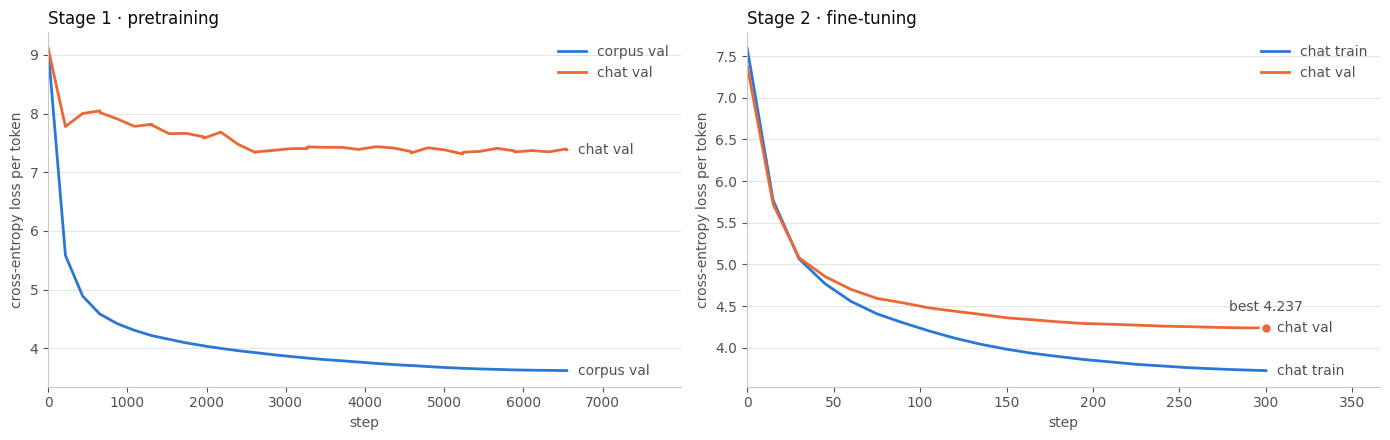

In [14]:
import matplotlib.pyplot as plt

COLORS = {"corpus val": "#2a78d6", "chat train": "#2a78d6", "chat val": "#eb6834"}
INK, MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#e6e5e0", "#c9c8c2"


def plot_stage(ax, history, title, best=None):
    names = [name for name in history if name != "step"]
    for name in names:
        ax.plot(history["step"], history[name], color=COLORS[name], lw=2, label=name)
    if best:
        ax.plot(best["step"], best["loss"], "o", ms=8, color=COLORS["chat val"], mec="white", mew=2, zorder=3)
        ax.annotate(f"best {best['loss']:.3f}", (best["step"], best["loss"]), xytext=(0, 10),
                    textcoords="offset points", ha="center", va="bottom", color=MUTED)
    # Direct labels at the end of each line, pushed apart when they end close together.
    ends = sorted((history[name][-1], name) for name in names)
    y_range = max(max(history[n]) for n in names) - min(min(history[n]) for n in names)
    if len(ends) == 2 and ends[1][0] - ends[0][0] < 0.06 * y_range:
        middle = (ends[0][0] + ends[1][0]) / 2
        ends = [(middle - 0.03 * y_range, ends[0][1]), (middle + 0.03 * y_range, ends[1][1])]
    for y, name in ends:
        ax.annotate(name, (history["step"][-1], y), xytext=(8, 0), textcoords="offset points", va="center", color=MUTED)
    ax.set_xlim(0, history["step"][-1] * 1.22)
    ax.set_title(title, loc="left", color=INK, fontsize=12)
    ax.set_xlabel("step", color=MUTED)
    ax.set_ylabel("cross-entropy loss per token", color=MUTED)
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(AXIS)
    ax.tick_params(colors=MUTED)
    ax.legend(frameon=False, loc="upper right", labelcolor=MUTED)


stages = ([(pretrain_history, "Stage 1 · pretraining", None)] if pretrain_history else []) + \
         [(finetune_history, "Stage 2 · fine-tuning", finetune_best)]
fig, axes = plt.subplots(1, len(stages), figsize=(7 * len(stages), 4.5), squeeze=False)
for ax, (history, title, best) in zip(axes[0], stages):
    plot_stage(ax, history, title, best)
plt.tight_layout()
plt.show()

## 13 · Save the model

- `kabyle_gpt.pt`: the fine-tuned chat model (weights, architecture and tokenizer in one file).
- `kabyle_gpt_pretrained.pt`: the model after stage 1. Upload it as a dataset and set `PRETRAINED_CHECKPOINT` to skip pretraining next time.

To download on Kaggle: *Output* panel on the right → `/kaggle/working` → file → ⋮ → Download.

In [ ]:
save_checkpoint(model, FINETUNED_PATH, stage="fine-tuned", step=checkpoint["step"], losses=checkpoint["losses"],
                chat_val_bits_per_char=bits_per_char(final_chat_val), pretrain_history=pretrain_history,
                finetune_history=finetune_history, n_params=n_params)
try:
    from IPython.display import FileLink, display
except ImportError:
    display = None
for path in (FINETUNED_PATH, PRETRAINED_CHECKPOINT or PRETRAINED_PATH):
    print(f"{path} ({os.path.getsize(path) / 1024**2:.0f} MB)")
    if display and path.startswith(OUTPUT_DIR):
        display(FileLink(os.path.relpath(path), result_html_prefix="Download: "))

/kaggle/working/kabyle_gpt.pt (139 MB)


/kaggle/working/kabyle_gpt.pt

/kaggle/working/kabyle_gpt_pretrained.pt (139 MB)


/kaggle/working/kabyle_gpt_pretrained.pt

## 14 · Talk to the model

`ask("…")` sends one message and prints the answer. Change `temperature`, `top_k`, `top_p` or `n_messages` to see how the answers change.

In [ ]:
ask("amek achu xedmed akka")
ask("Azul, amek telid ?")
ask("Achu txedmed ass agi ?")
ask("Bonne nuit")
ask("amek achu xedmed akka", temperature=1.1, n_messages=5)

`chat()` starts a conversation that remembers what was said, within the 512-token context.
Type `reset` to start over and `quit` to stop. It needs an interactive session.

In [ ]:
chat()

## 15 · Use the saved model later

In a new session (on Kaggle, add `kabyle_gpt.pt` as a dataset): run **1 · Setup**, **2 · Configuration**,
**7 · Model architecture** (first code cell) and **8 · Text generation**, then the cell below with the path to your file.

In [ ]:
from tokenizers import Tokenizer


def load_kabyle_gpt(path):
    """Return (model, tokenizer, id of the <|msg|> token) from a saved kabyle_gpt.pt."""
    ckpt = torch.load(path, map_location=DEVICE, weights_only=True)
    loaded_tokenizer = Tokenizer.from_str(ckpt["tokenizer"])
    loaded_model = KabyleGPT(ModelConfig(**ckpt["model_config"])).to(DEVICE)
    loaded_model.load_state_dict(ckpt["model"])
    return loaded_model.eval(), loaded_tokenizer, loaded_tokenizer.token_to_id(ckpt["msg_token"])


# Uncomment, set the path and run:
# model, tokenizer, MSG_ID = load_kabyle_gpt("/kaggle/input/<your-dataset>/kabyle_gpt.pt")
# ask("amek achu xedmed akka")